In [1]:
# import packages

# general tools
import numpy as np
import os
import pandas as pd
# RDkit
from rdkit import Chem
from rdkit.Chem.rdmolops import GetAdjacencyMatrix

# Pytorch and Pytorch Geometric
import torch
import torch_geometric
from torch.nn import Linear
from torch_geometric.data import Data
from torch.utils.data import DataLoader
from torch_geometric.data import DataLoader, Batch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn
from torch_geometric.nn import global_mean_pool
from torch_geometric.data import InMemoryDataset 



#jindutiao
from tqdm import tqdm
from datetime import datetime
from colorama import Fore, Back
import time
import random
import math

# 可视化部分
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
import seaborn as sns
import mdapy as mp
from mdapy import pltset, cm2inch


from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

import warnings
warnings.filterwarnings('ignore')

[Taichi] version 1.7.0, llvm 15.0.4, commit 2fd24490, linux, python 3.8.16


[I 01/03/24 22:02:34.578 81] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


In [2]:
import torch_geometric.transforms as T
from torch_geometric.utils import remove_self_loops, to_dense_adj, dense_to_sparse
from torch_geometric.nn import MessagePassing, global_mean_pool
from torch_scatter import scatter


class MPNNLayer(MessagePassing):
    def __init__(self, emb_dim=256, edge_dim=10, aggr='add'):
        """Message Passing Neural Network Layer

        Args:
            emb_dim: (int) - hidden dimension `d`
            edge_dim: (int) - edge feature dimension `d_e`
            aggr: (str) - aggregation function `\oplus` (sum/mean/max)
        """
        # Set the aggregation function
        super().__init__(aggr=aggr)

        self.emb_dim = emb_dim
        self.edge_dim = edge_dim

        # MLP `\psi` for computing messages `m_ij`
        # Implemented as a stack of Linear->BN->ReLU->Linear->BN->ReLU
        # dims: (2d + d_e) -> d
        self.mlp_msg = Sequential(
            Linear(2*emb_dim + edge_dim, emb_dim), BatchNorm1d(emb_dim), ReLU(),
            Linear(emb_dim, emb_dim), BatchNorm1d(emb_dim), ReLU()
          )
        
        # MLP `\phi` for computing updated node features `h_i^{l+1}`
        # Implemented as a stack of Linear->BN->ReLU->Linear->BN->ReLU
        # dims: 2d -> d
        self.mlp_upd = Sequential(
            Linear(2*emb_dim, emb_dim), BatchNorm1d(emb_dim), ReLU(), 
            Linear(emb_dim, emb_dim), BatchNorm1d(emb_dim), ReLU()
          )

    def forward(self, h, edge_index, edge_attr):
        """
        The forward pass updates node features `h` via one round of message passing.

        As our MPNNLayer class inherits from the PyG MessagePassing parent class,
        we simply need to call the `propagate()` function which starts the 
        message passing procedure: `message()` -> `aggregate()` -> `update()`.
        
        The MessagePassing class handles most of the logic for the implementation.
        To build custom GNNs, we only need to define our own `message()`, 
        `aggregate()`, and `update()` functions (defined subsequently).

        Args:
            h: (n, d) - initial node features
            edge_index: (e, 2) - pairs of edges (i, j)
            edge_attr: (e, d_e) - edge features

        Returns:
            out: (n, d) - updated node features
        """
        out = self.propagate(edge_index, h=h, edge_attr=edge_attr)
        return out

    def message(self, h_i, h_j, edge_attr):
        """Step (1) Message

        The `message()` function constructs messages from source nodes j 
        to destination nodes i for each edge (i, j) in `edge_index`.

        The arguments can be a bit tricky to understand: `message()` can take 
        any arguments that were initially passed to `propagate`. Additionally, 
        we can differentiate destination nodes and source nodes by appending 
        `_i` or `_j` to the variable name, e.g. for the node features `h`, we
        can use `h_i` and `h_j`. 
        
        This part is critical to understand as the `message()` function
        constructs messages for each edge in the graph. The indexing of the
        original node features `h` (or other node variables) is handled under
        the hood by PyG.

        Args:
            h_i: (e, d) - destination node features
            h_j: (e, d) - source node features
            edge_attr: (e, d_e) - edge features
        
        Returns:
            msg: (e, d) - messages `m_ij` passed through MLP `\psi`
        """
        msg = torch.cat([h_i, h_j, edge_attr], dim=-1)
        return self.mlp_msg(msg)
    
    def aggregate(self, inputs, index):
        """Step (2) Aggregate

        The `aggregate` function aggregates the messages from neighboring nodes,
        according to the chosen aggregation function ('sum' by default).

        Args:
            inputs: (e, d) - messages `m_ij` from destination to source nodes
            index: (e, 1) - list of source nodes for each edge/message in `input`

        Returns:
            aggr_out: (n, d) - aggregated messages `m_i`
        """
        return scatter(inputs, index, dim=self.node_dim, reduce=self.aggr)
    
    def update(self, aggr_out, h):
        """
        Step (3) Update

        The `update()` function computes the final node features by combining the 
        aggregated messages with the initial node features.

        `update()` takes the first argument `aggr_out`, the result of `aggregate()`, 
        as well as any optional arguments that were initially passed to 
        `propagate()`. E.g. in this case, we additionally pass `h`.

        Args:
            aggr_out: (n, d) - aggregated messages `m_i`
            h: (n, d) - initial node features

        Returns:
            upd_out: (n, d) - updated node features passed through MLP `\phi`
        """
        upd_out = torch.cat([h, aggr_out], dim=-1)
        return self.mlp_upd(upd_out)

    def __repr__(self) -> str:
        return (f'{self.__class__.__name__}(emb_dim={self.emb_dim}, aggr={self.aggr})')

In [3]:
from torch.nn import Linear, ReLU, BatchNorm1d, Module, Sequential


class MPNNModel(Module):
    def __init__(self, num_layers=2, emb_dim=256, in_dim=42, edge_dim=10, out_dim=1):
        """Message Passing Neural Network model for graph property prediction

        Args:
            num_layers: (int) - number of message passing layers `L`
            emb_dim: (int) - hidden dimension `d`
            in_dim: (int) - initial node feature dimension `d_n`
            edge_dim: (int) - edge feature dimension `d_e`
            out_dim: (int) - output dimension (fixed to 1)
        """
        super().__init__()
        
        # Linear projection for initial node features
        # dim: d_n -> d
        self.lin_in = Linear(in_dim, emb_dim)
        
        # Stack of MPNN layers
        #self.conv = MPNNLayer(emb_dim, edge_dim, aggr='add')
        self.convs = torch.nn.ModuleList()
        for layer in range(num_layers):
            self.convs.append(MPNNLayer(emb_dim, edge_dim, aggr='add'))
        
        # Global pooling/readout function `R` (mean pooling)
        # PyG handles the underlying logic via `global_mean_pool()`
        self.pool = global_mean_pool

        # Linear prediction head
        # dim: d -> out_dim
        self.lin_pred = Linear(emb_dim, out_dim)
        
        self.graph_data = None
        
    def forward(self, data):
        """
        Args:
            data: (PyG.Data) - batch of PyG graphs

        Returns: 
            out: (batch_size, out_dim) - prediction for each graph
        """
        h = self.lin_in(data.x) # (n, d_n) -> (n, d)
        
        for conv in self.convs:
            h = h + conv(h, data.edge_index, data.edge_attr) # (n, d) -> (n, d)

        h_graph = self.pool(h, data.batch) # (n, d) -> (batch_size, d)
        
        self.graph_data = h_graph

        out = self.lin_pred(h_graph) # (batch_size, d) -> (batch_size, 1)

        return out.view(-1)

In [4]:
# Instantiate temporary model, layer, and dataloader for unit testing
# layer = MPNNLayer(emb_dim=256, edge_dim=10)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

model = MPNNModel(num_layers=2, emb_dim=256, in_dim=42, edge_dim=10, out_dim=1).to(device)

cuda


In [5]:
# 加载保存的模型参数
model.load_state_dict(torch.load('./stateGNN.pt'))
model.eval()  # 设置模型为评估模式

MPNNModel(
  (lin_in): Linear(in_features=42, out_features=256, bias=True)
  (convs): ModuleList(
    (0): MPNNLayer(emb_dim=256, aggr=add)
    (1): MPNNLayer(emb_dim=256, aggr=add)
  )
  (lin_pred): Linear(in_features=256, out_features=1, bias=True)
)

In [7]:
from graphdataset import MyDataset

dataset = torch.load('./dataset/dataset.pth')

In [9]:
print(dataset[0])
print(dataset[0].y)
print(dataset[1])
batch_size = 128  # 设置每个小批次的大小
# create dataloader for training
test_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

Data(x=[4, 42], edge_index=[2, 8], edge_attr=[8, 10], y=[1])
tensor([1.])
Data(x=[4, 42], edge_index=[2, 8], edge_attr=[8, 10], y=[1])


In [10]:
len(dataset)

7

In [11]:
optimizer = torch.optim.Adam(model.parameters(),lr=0.001,weight_decay=5e-4)
loss_function = nn.MSELoss()
loss_function = loss_function.to(device)

In [12]:
def eval(loader):
    y_true = []
    y_pred = []
    loss_function_value = 0
    model.eval()
    error = 0
    for data in test_loader:
        data = data.to(device)
        with torch.no_grad():
            output = model(data)#data数据传入模型
            #print(output)
            label = data.y
            label = label.to(device)
            #print('value label',label)
            #print('label_tensor',torch.tensor(label, dtype = torch.float32))
            loss_function_value = loss_function(output, torch.tensor(label, dtype = torch.float32))
            error += loss_function_value.item() * batch_size
            
            y_true.extend(label.detach().cpu().squeeze().numpy().tolist())
            y_pred.extend(output.detach().cpu().squeeze().numpy().tolist())
      
    loader_error = error / len(loader.dataset)    
    # 全量样本的rmse和平均loss
    MAE = mean_absolute_error(y_true, y_pred)
    MSE = mean_squared_error(y_true, y_pred) 
    RMSE = math.sqrt(mean_squared_error(y_true, y_pred))
    R2 = r2_score(y_true,y_pred)
    # 保留4位小数
    R2 = np.round(R2, 4)
    MAE = np.round(MAE, 4)
    RMSE = np.round(RMSE, 4)
    MSE = np.round(MSE, 4)
    return  loader_error, R2, MAE, RMSE, MSE,y_true,y_pred

test_error,test_R2,test_MAE, test_RMSE, test_MSE,y_true,y_pred = eval(test_loader)

In [13]:
print(y_true)

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


In [14]:
print(y_pred)

[111.4253158569336, 89.2858657836914, -205.87657165527344, -120.99335479736328, -47.54927062988281, -9.659802436828613, 30.77143669128418]


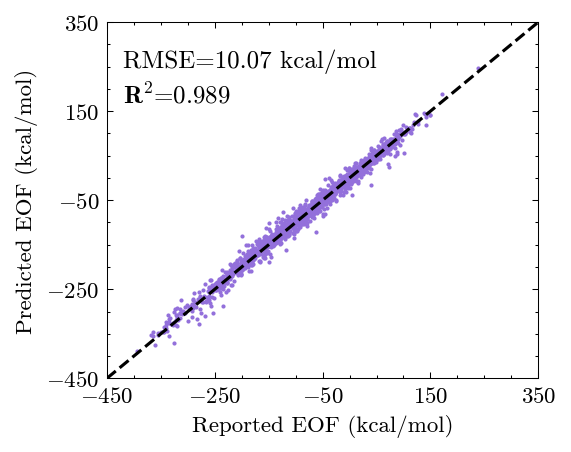

In [16]:
from matplotlib.colors import Normalize


pltset()
colorlist = [i["color"] for i in list(plt.rcParams["axes.prop_cycle"])]
fig = plt.figure(figsize=(cm2inch(10), cm2inch(8)), dpi=150)
plt.scatter(y_true, y_pred, s=1,color='mediumpurple')  

#绘制对角线
start_point = (-450, -450)
end_point = (350, 350)
plt.axline(start_point, end_point, color='black', linestyle='--') #
# plt.xlabel("Reported EOF (kcal/mol)")
# plt.ylabel("Predicted EOF (kcal/mol)")
# plt.xlim(-450,320)
# plt.ylim(-450,320)
# #plt.axis('equal')

plt.xlabel("Reported EOF (kcal/mol)",weight='bold')
plt.ylabel("Predicted EOF (kcal/mol)",weight='bold')
plt.xlim(-450,350)
plt.ylim(-450,350)
plt.xticks([-450, -250, -50,150,350])  # 指定 x 轴刻度值
plt.yticks([-450, -250, -50,150,350]) 

# plt.grid(alpha=0.6,linestyle='--') 
plt.text(
    -420,
    250,
    r"RMSE=%.2f kcal/mol"
    % math.sqrt(mean_squared_error(y_true, y_pred)),
    fontsize=12
    )
plt.text(-420,170,r"$\bf{R^2}$=%.3f" % r2_score(y_true, y_pred),fontsize=12)
plt.tight_layout()

plt.savefig('./png/scattertest.png')
plt.show()